# Prédiction

## Occupation en fonction de l'heure

In [53]:
from ipywidgets import HBox, VBox, Box, fixed, interactive_output
from plotly.graph_objects import FigureWidget
from IPython.display import display
from pycaret.classification import setup, compare_models, plot_model

import pandas as pd
import plotly.express as px
import sys
import os

sys.path.append(os.path.abspath("./"))
import helpers as _

In [62]:
df = pd.read_csv('./Followchon/data/df_occupation.csv')

columns = ['date', 'hour', 'occupation', 'class', 'T', 'zone']
mask = df['zone'].str.contains('|'.join(['Clapier', 'Fontaine', 'Loft', 'Cachette', 'Foin'])) \
    & df['hour'].between(9, 19)

df_occupation = df.loc[mask, columns]

df_occupation

,date,hour,occupation,class,T,zone
0,2024-07-21,15,0.018056,Noisette,26.6,Clapier
1,2024-07-21,16,0.003333,Noisette,25.5,Clapier
2,2024-07-21,17,0.001111,Noisette,25.1,Clapier
3,2024-07-21,18,0.005278,Noisette,25.1,Clapier
4,2024-07-21,19,0.000278,Noisette,24.7,Clapier
...,...,...,...,...,...,...
7145,2024-11-03,10,0.083333,Stitch,12.1,Foin
7146,2024-11-03,13,0.133333,Stitch,13.6,Foin
7147,2024-11-03,14,0.166667,Stitch,14.3,Foin
7148,2024-11-03,15,0.350000,Stitch,14.4,Foin


- Parle-t-on de problème supervisée ou non supervisée ?
  - On est face à un problème supervisé car nous avons des données à disposition pour l'entrainement
- Les données sont-elles stucturées ou non structurées ?
    - Les données sont structurées avec en ligne les dates et en colonnes les features (suivant le modèle relationnel)
- Est-ce un problème de régression ou de classification ? Aucun des deux ?
    - Si on cherche à déterminer l'occupation en fonction de l'heure sur une zone déterminé, c'est un problème de régression
    - Si on cherche à déterminer la zone occupé en fonction de l'heure, c'est un problème de classification
- Quelles sont les features et quelle est la target ?
    - Target :
        - Soit l'occupation
        - Soit la zone
    - Features :
        - date
        - heure
        - température
        - class

- suppression des colonnes inutiles (customer_id)
- suppressions des valeurs absurdes (valeurs négatives de average_price)
- dummification des valeurs textuelles avec labelencoder pour la target (client_type) et onehotencoder pour les features (country, gender)
- normalisation des features numériques (average_basket, average_price, visit_number, age)
- concaténation des résultats dans une seule variable X

In [40]:
exp = setup(
    data=df_occupation,
    target="zone",
    session_id=42
)

,Description,Value
0,Session id,42
1,Target,zone
2,Target type,Multiclass
3,Target mapping,"Cachette: 0, Clapier: 1, Foin: 2, Fontaine: 3, Loft: 4"
4,Original data shape,"(4086, 6)"
5,Transformed data shape,"(4086, 6)"
6,Transformed train set shape,"(2860, 6)"
7,Transformed test set shape,"(1226, 6)"
8,Numeric features,3
9,Categorical features,2


In [41]:
best_model = compare_models(exclude=['lightgbm'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.6867,0.7938,0.6867,0.6887,0.6863,0.5813,0.5820,0.0370
rf,Random Forest Classifier,0.6825,0.8616,0.6825,0.6851,0.6816,0.5741,0.5750,0.2110
et,Extra Trees Classifier,0.6367,0.8291,0.6367,0.6370,0.6352,0.5122,0.5129,0.1950
gbc,Gradient Boosting Classifier,0.4741,0.0000,0.4741,0.4710,0.4613,0.2882,0.2927,0.5280
ridge,Ridge Classifier,0.4010,0.0000,0.4010,0.3679,0.3585,0.1693,0.1746,0.0350
nb,Naive Bayes,0.3916,0.6664,0.3916,0.4192,0.3658,0.2017,0.2191,0.0350
lr,Logistic Regression,0.3839,0.0000,0.3839,0.3586,0.3623,0.1582,0.1607,0.2370
lda,Linear Discriminant Analysis,0.3825,0.0000,0.3825,0.3605,0.3584,0.1495,0.1528,0.0350
qda,Quadratic Discriminant Analysis,0.3822,0.0000,0.3822,0.4185,0.3613,0.1904,0.2050,0.0340
ada,Ada Boost Classifier,0.3479,0.0000,0.3479,0.3493,0.3428,0.1337,0.1351,0.0950


/home/jaden/Projects/followchon_back/venv/lib/python3.11/site-packages/pycaret/internal/pycaret_experiment/supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


In [45]:
df = pd.read_csv('Followchon/data/df_detections_t.csv')

columns = ['datetime', 'date', 'hour', 'T', 'class', 'zone']
mask = (~df['zone'].isnull()) \
    & df['zone'].str.contains('|'.join(['Clapier', 'Fontaine', 'Loft', 'Cachette', 'Foin'])) \
    & df['hour'].between(9, 19)

df_detection = df.loc[mask, columns]
df_detection

,datetime,date,hour,T,class,zone
0,2024-07-21 13:18:01,2024-07-21,13,NaN,Noisette,Clapier
2,2024-07-21 13:19:15,2024-07-21,13,NaN,Stitch,Cachette
5,2024-07-21 13:22:16,2024-07-21,13,NaN,Noisette,Cachette
6,2024-07-21 13:23:10,2024-07-21,13,NaN,Stitch,Cachette
11,2024-07-21 13:30:05,2024-07-21,13,NaN,Stitch,Cachette
...,...,...,...,...,...,...
53468,2024-11-19 09:34:01,2024-11-19,9,NaN,Noisette,Clapier
53469,2024-11-19 09:34:01,2024-11-19,9,NaN,Noisette,Cachette
53470,2024-11-19 09:41:01,2024-11-19,9,NaN,Noisette,Foin
53471,2024-11-19 09:41:01,2024-11-19,9,NaN,Noisette,Cachette


In [46]:
exp = setup(
    data=df_detection,
    target="zone",
    session_id=42
)

,Description,Value
0,Session id,42
1,Target,zone
2,Target type,Multiclass
3,Target mapping,"Cachette: 0, Clapier: 1, Foin: 2, Fontaine: 3, Loft: 4"
4,Original data shape,"(23960, 6)"
5,Transformed data shape,"(23960, 6)"
6,Transformed train set shape,"(16772, 6)"
7,Transformed test set shape,"(7188, 6)"
8,Numeric features,2
9,Categorical features,3


In [47]:
best_model = compare_models(exclude=['lr', 'gbc', 'lightgbm'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.5281,0.7442,0.5281,0.5263,0.5234,0.3619,0.3633,0.6830
dt,Decision Tree Classifier,0.5256,0.7033,0.5256,0.5207,0.5184,0.3437,0.3455,0.1260
et,Extra Trees Classifier,0.5225,0.7406,0.5225,0.5304,0.5204,0.3524,0.3548,0.5850
knn,K Neighbors Classifier,0.5187,0.7359,0.5187,0.5185,0.5101,0.3339,0.3353,0.1580
lda,Linear Discriminant Analysis,0.4652,0.0000,0.4652,0.3951,0.3948,0.2151,0.2350,0.1200
nb,Naive Bayes,0.4526,0.6754,0.4526,0.3951,0.3970,0.2133,0.2255,0.1210
qda,Quadratic Discriminant Analysis,0.4468,0.0000,0.4468,0.4237,0.4148,0.2119,0.2189,0.1190
ridge,Ridge Classifier,0.4421,0.0000,0.4421,0.3428,0.3457,0.1430,0.1741,0.1220
ada,Ada Boost Classifier,0.4244,0.0000,0.4244,0.4318,0.4158,0.2215,0.2261,0.3420
dummy,Dummy Classifier,0.3929,0.5000,0.3929,0.1544,0.2217,0.0000,0.0000,0.1150


/home/jaden/Projects/followchon_back/venv/lib/python3.11/site-packages/pycaret/internal/pycaret_experiment/supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


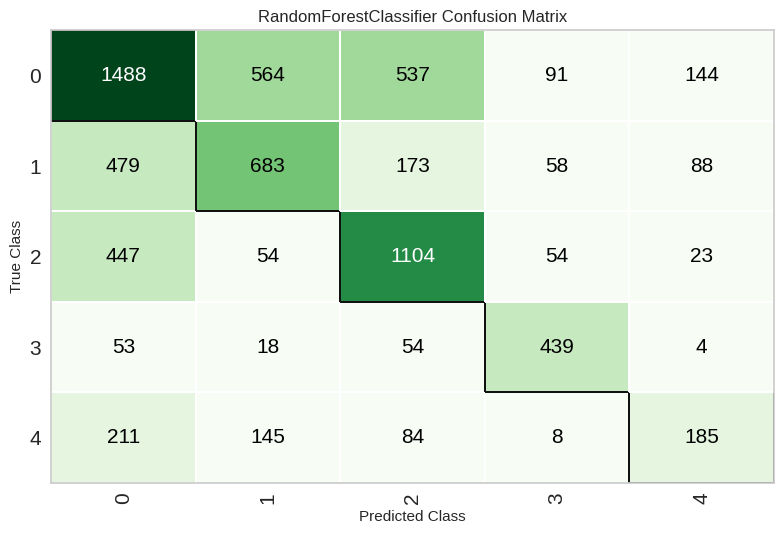

In [48]:
plot_model(best_model, plot='confusion_matrix')

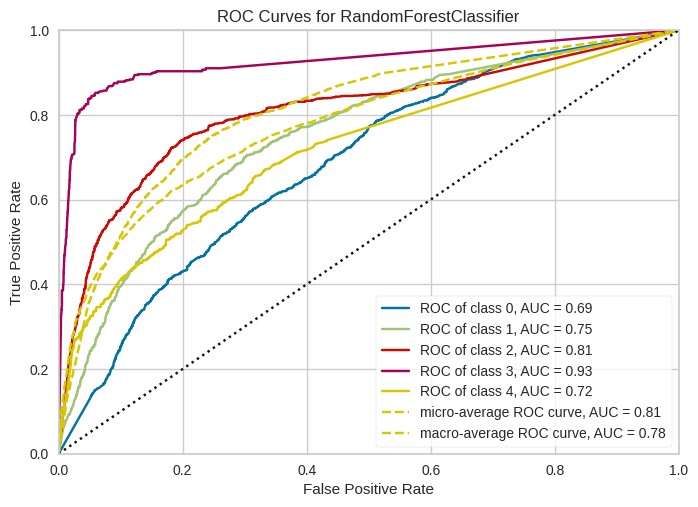

In [49]:
plot_model(best_model, plot='auc')